# SUIA/RTH Project LLM — Architecture, Technical Design & Implementation Roadmap

Yes. This is the Project LLM I recommend building. Your description establishes the correct product boundary: Project LLM is an AI-assisted software engineering, integration, verification and certification-readiness platform, not a chatbot, educational content generator or autonomous publishing system.

We will follow your requested sequence:

1. Architecture Blueprint — components, responsibilities, boundaries, workflows, governance and technical decisions.
2. TypeScript Code Structure — repository organization, interfaces, modules, APIs, database design and implementation patterns.
3. End-to-End MVP Plan — implementation stages, acceptance criteria, testing, evidence and a real pilot block.

One qualification: I am treating the lifecycle and contract descriptions you supplied as the working requirements. Before implementation, we must reconcile them against the authoritative repository files. We should not claim that the existing locked Phase 1B contract already authorizes this broader product.

## 1. Product definition and architectural decisions

| Question                                   | Decision                                    |
| ------------------------------------------ | ------------------------------------------- |
| What is Project LLM?                       | Block engineering and verification platform |
| Does it write tutorial content?            | No                                          |
| Does it design the block prototype?        | No; external AI does                        |
| Does it integrate candidate blocks?        | Yes, within authorized boundaries           |
| Does it change universal infrastructure?   | No, without explicit authorization          |
| Does it need a paid LLM API?               | No                                          |
| Does it initially need a local LLM?        | No                                          |
| Can it later support Ollama/vLLM?          | Yes                                         |
| Who approves the prototype?                | Human, Gate 1                               |
| Who certifies the final block?             | Human, Gate 2                               |
| Who generates verification evidence?       | Project LLM's deterministic tooling         |
| Can AI-generated claims count as evidence? | No                                          |

Our architectural principle:

> Deterministic software performs discovery, enforcement, integration, testing and evidence collection. AI assists with reasoning and explanation where useful. Human authority controls approvals and architectural exceptions.

This gives you a practical implementation that can start without GPU infrastructure or paid model subscriptions.

# Part 1 — Architecture Blueprint

## 2. Target architecture

The architecture should separate five concerns: user interaction, workflow orchestration, repository engineering, verification, and optional AI assistance.



flowchart TD
    H["Human Architecture Authority"]
    UI["Project LLM GUI"]
    WF["Workflow Orchestrator"]
    GOV["Governance and Policy Engine"]

    DISC["Repository Discovery"]
    BRIEF["Creation Brief Generator"]
    INTAKE["Candidate Intake"]
    AUDIT["Candidate Audit"]
    INTEG["Integration Engine"]
    TEST["Verification Engine"]
    EVID["Evidence and Certification Readiness"]

    EXT["External AI: Gemini / Claude / GPT"]
    REPO["Existing SUIA/RTH Repository"]
    MODEL["Optional Local/Hosted LLM"]

    H --> UI
    UI --> WF
    WF <--> GOV
    WF --> DISC
    DISC --> REPO
    DISC --> BRIEF
    BRIEF --> UI
    UI -. "Human copies brief" .-> EXT
    EXT -. "Human returns candidate" .-> UI
    UI --> INTAKE
    INTAKE --> AUDIT
    AUDIT --> INTEG
    INTEG --> TEST
    TEST --> EVID
    EVID --> UI
    WF -. "Optional reasoning" .-> MODEL
    INTEG --> REPO

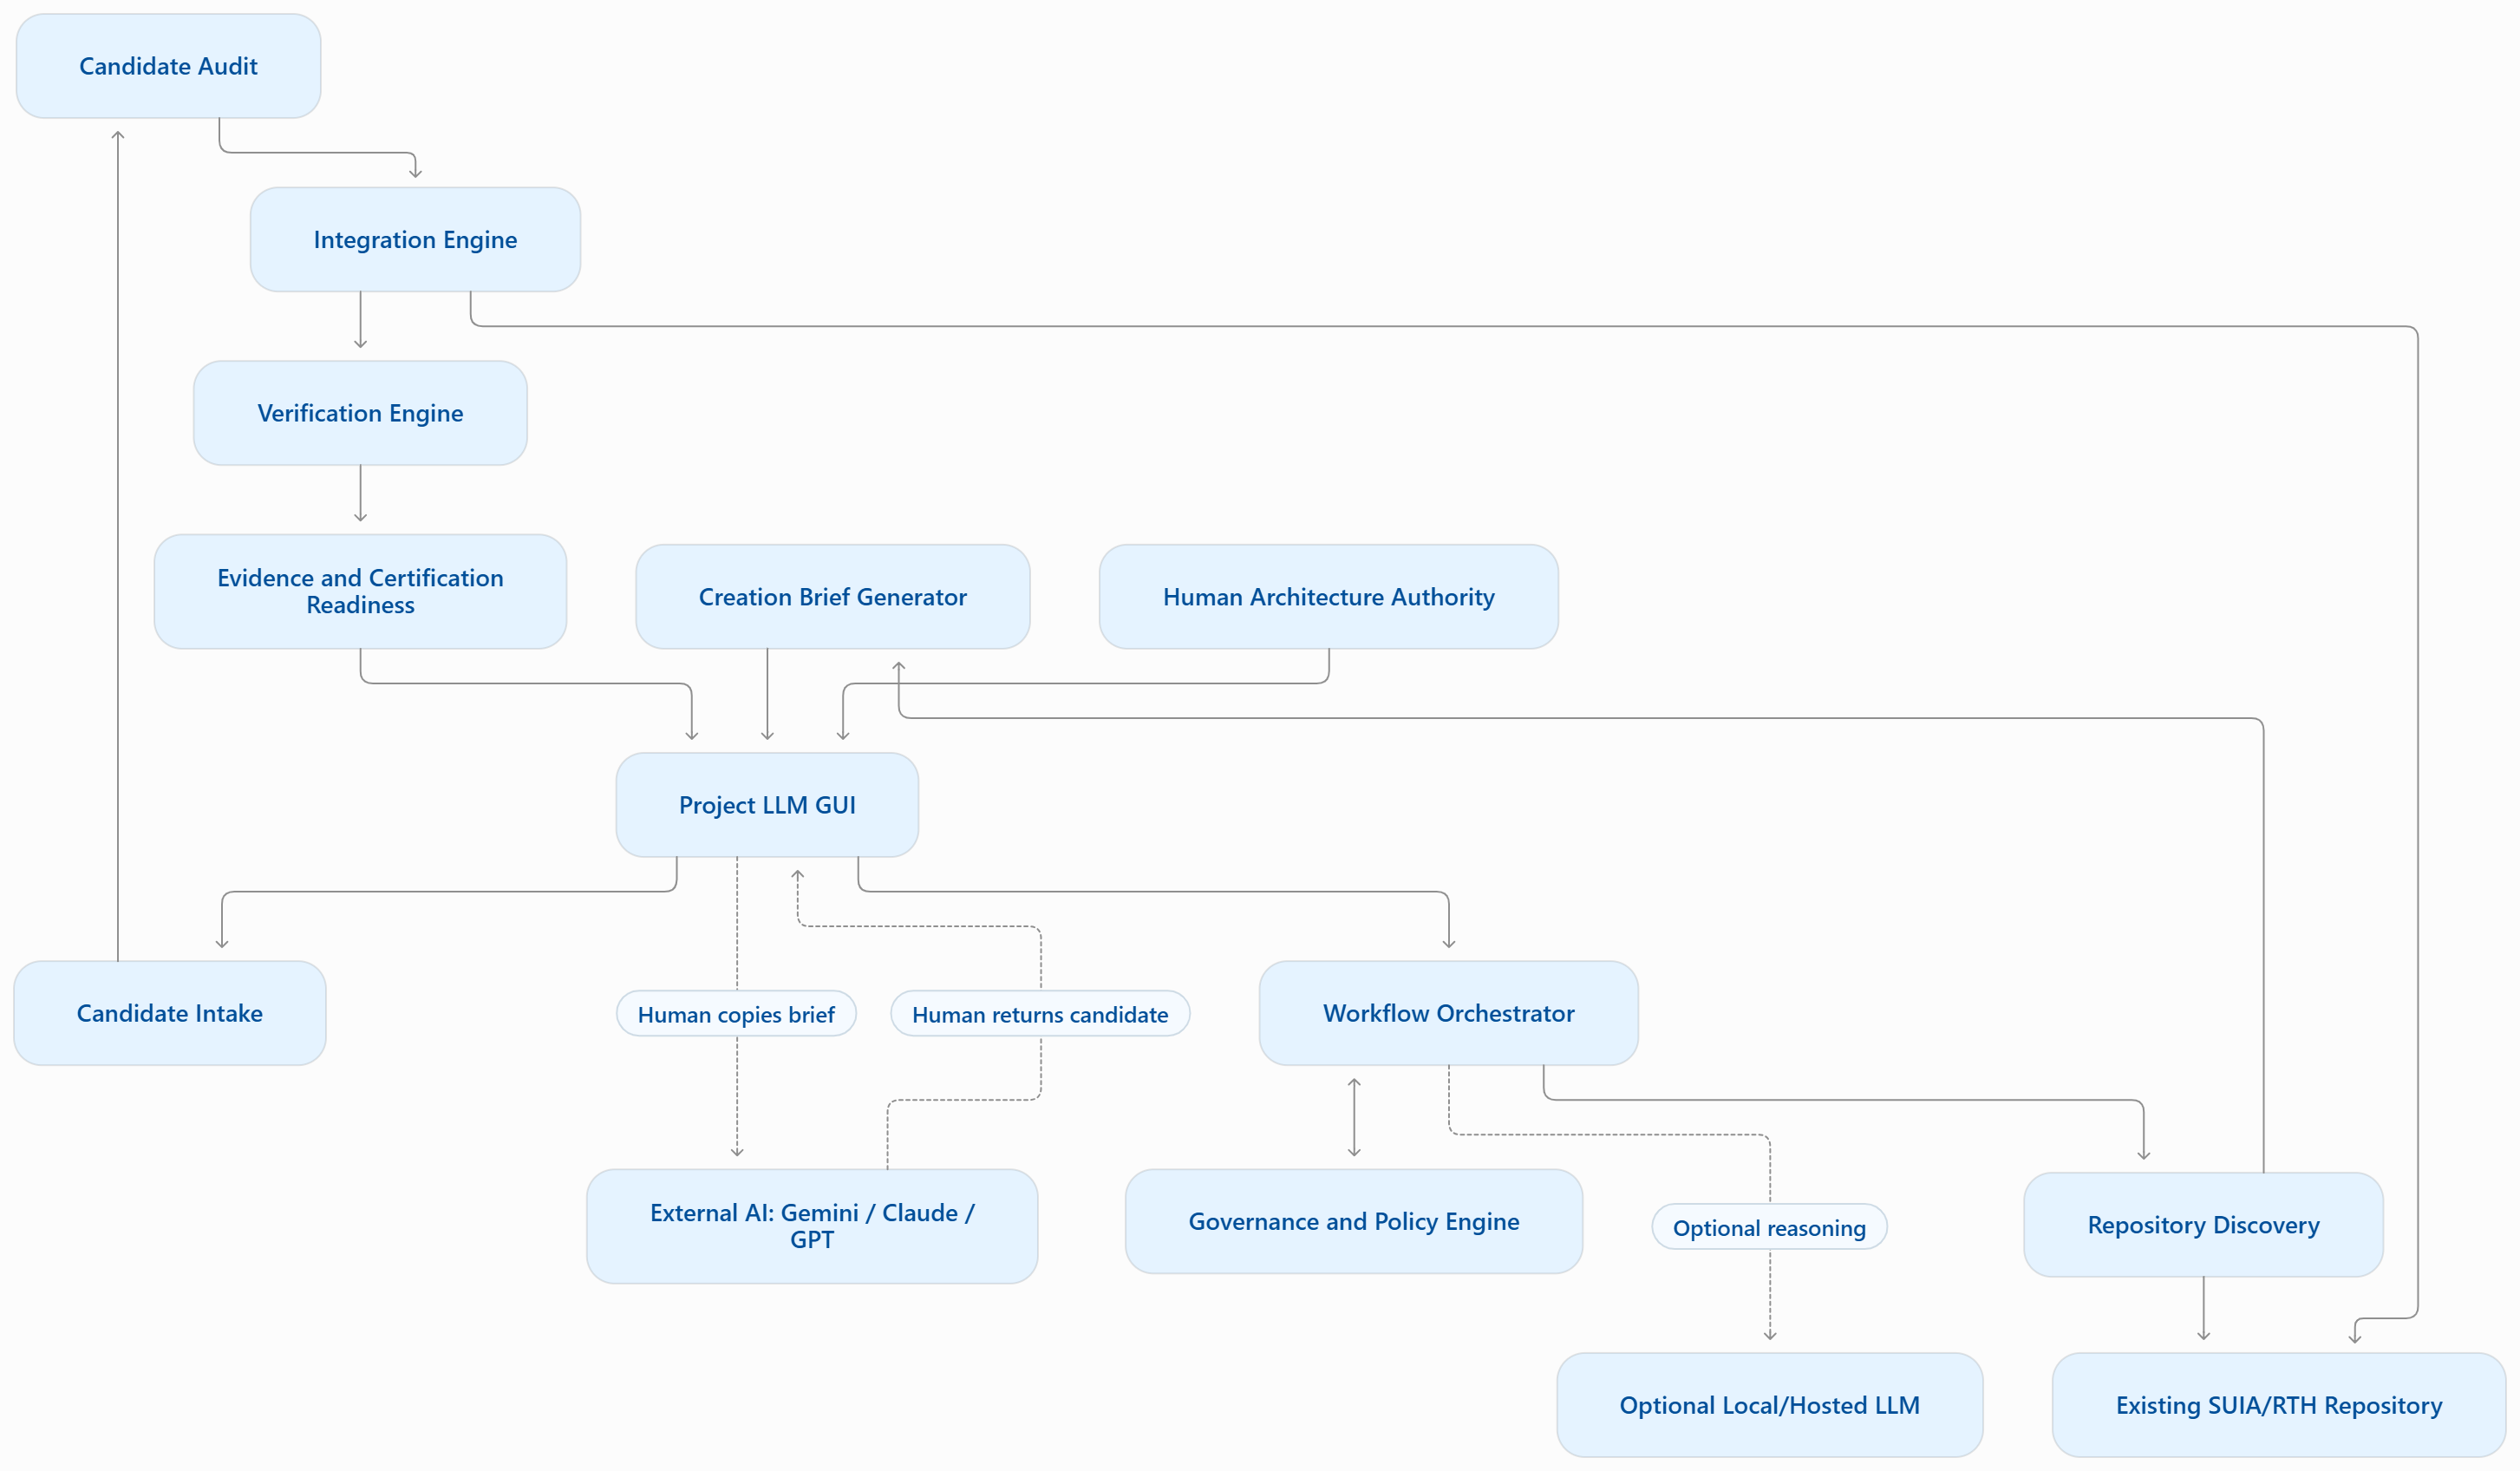

The diagram represents logical responsibilities, not necessarily separate microservices. For the MVP, use a modular monolith and isolated worker processes, not Kubernetes or a distributed multi-agent system.

### 2.1 Core modules

| Module                | Responsibility                             | Technology                   |
| --------------------- | ------------------------------------------ | ---------------------------- |
| Project LLM GUI       | Workflow, approvals, evidence review       | Existing Next.js/React stack |
| Workflow Orchestrator | Lifecycle and state transitions            | TypeScript                   |
| Repository Discovery  | Read repository structure and contracts    | Git, TypeScript AST          |
| Brief Generator       | Produce external-AI instructions           | Versioned templates          |
| Candidate Intake      | Receive and inventory files                | TypeScript, parsers          |
| Candidate Auditor     | Inspect structure and forbidden operations | TypeScript AST, rules        |
| Integration Engine    | Prepare controlled integration patches     | TypeScript                   |
| Verification Engine   | Run required validation suites             | Existing test tools          |
| Governance Engine     | Enforce approval and change boundaries     | Policy-as-code               |
| Evidence Ledger       | Record reproducible results                | PostgreSQL, artifact storage |
| Model Gateway         | Optional AI reasoning                      | Provider interface           |

Do not introduce an independent service for each module. Keep modules separate in code, then split deployments only when operational requirements justify it.

## 3. Lifecycle architecture

I recommend implementing your external-AI block lifecycle as the following state machine.


In [ ]:
flowchart TD
    A["REQUESTED"] --> B["DISCOVERY"]
    B --> C{"Repository baseline valid?"}
    C -- No --> X["BLOCKED / ESCALATED"]
    C -- Yes --> D["BRIEF_READY"]
    D --> E["EXTERNAL_PROTOTYPE"]
    E --> F{"Gate 1: Human approval"}
    F -- Reject --> E
    F -- Approve --> G["CANDIDATE_REQUESTED"]
    G --> H["CANDIDATE_RECEIVED"]
    H --> I["AUDITING"]
    I --> J{"Candidate acceptable?"}
    J -- Repairable --> R["REVISION_REQUIRED"]
    R --> H
    J -- Boundary violation --> X
    J -- Yes --> K["INTEGRATING"]
    K --> L["VERIFYING"]
    L --> M{"All required checks pass?"}
    M -- Repairable failure --> R
    M -- Unresolved blocker --> X
    M -- Yes --> N["CERTIFICATION_READY"]
    N --> O{"Gate 2: Human decision"}
    O -- Reject --> P["REJECTED"]
    O -- Approve --> Q["CERTIFIED"]

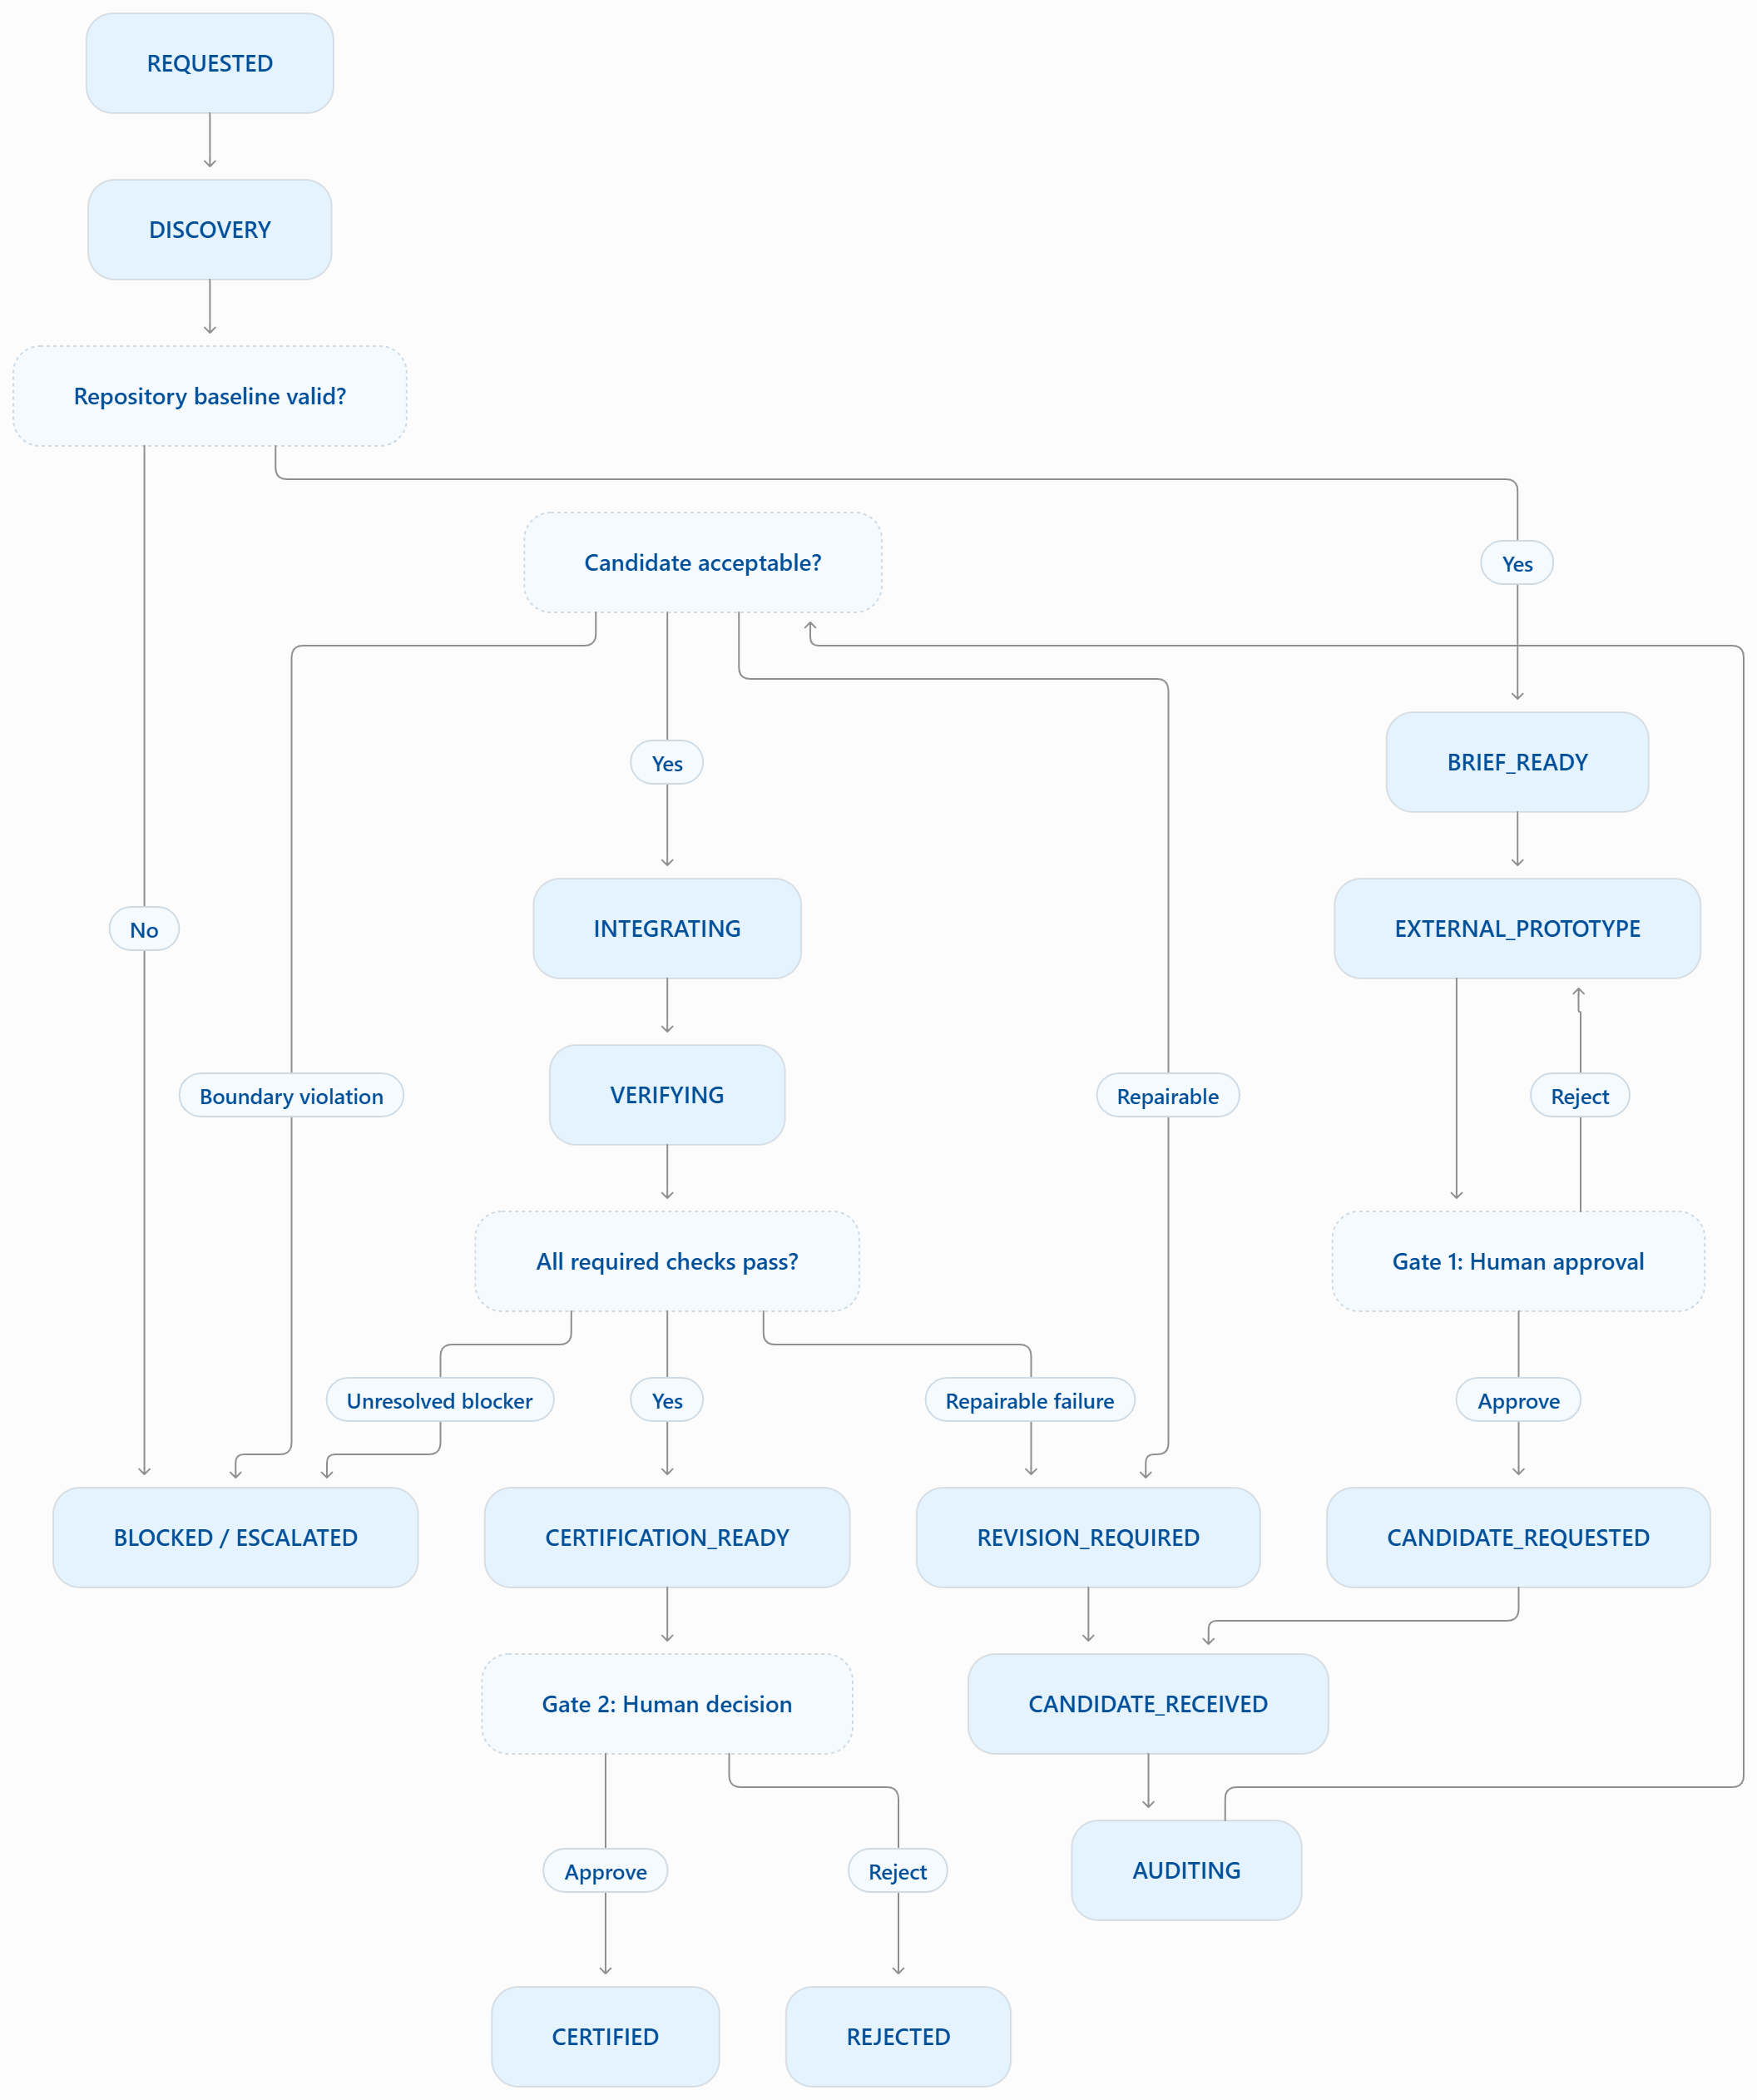




Two critical rules:

Rule A: `CERTIFICATION_READY` is not equivalent to `CERTIFIED`.

Rule B: A failing or unavailable mandatory check must never be silently converted into PASS. `NOT_APPLICABLE` is allowed only when the applicable contract permits it and records the justification.

### 3.1 The integration boundary

The Integration Engine must not blindly modify the live repository.

Use this process:

```
Candidate package
       |
       v
Isolated intake directory
       |
       v
Static analysis
       |
       v
Integration plan
       |
       v
Policy validation
       |
       v
Isolated Git worktree
       |
       v
Apply approved-scope changes
       |
       v
Compile + test + inspect
       |
       v
Produce patch + evidence
       |
       v
Human-controlled acceptance
```

A Git worktree provides an isolated checkout, but it is not a security sandbox. Untrusted candidate code must execute in a separately restricted environment with no production secrets, no privileged mounts, no unrestricted network access and resource limits.

## 4. Platform compatibility architecture

Project LLM must integrate with the platform you already have.

Your supplied requirements identify:

- Tutorial Composer
- Block schemas
- Block renderer
- UBRC
- ILS
- LSNB
- RSSB

We should not invent what each subsystem's internal contracts require. Repository discovery must establish those details.

### Compatibility verification matrix

| Area          | Verification requirement                                 |
| ------------- | -------------------------------------------------------- |
| Composer      | Existing creation/editing workflow remains authoritative |
| Schema        | Candidate conforms to the applicable versioned schema    |
| Renderer      | Block renders through the existing registry/path         |
| UBRC          | Applicable universal block runtime contracts pass        |
| ILS           | Applicable integration requirements pass                 |
| LSNB          | Applicable navigation requirements pass                  |
| RSSB          | Applicable runtime/sidebar requirements pass             |
| SSR           | No invalid server/client execution behavior              |
| Accessibility | Required accessibility tests pass                        |
| Responsive    | Supported viewport behavior is verified                  |
| Security      | Forbidden operations and dependencies are checked        |
| Regression    | Existing blocks and workflows remain functional          |

The checks should be generated from actual repository contracts, not guessed from subsystem names.

### 4.1 An important architectural decision

Project LLM must not create a second Composer.

Its integration module should produce changes compatible with the existing Composer and renderer.

For example:

```
Project LLM
    |
    +-- discovers existing block registry
    |
    +-- identifies required registration contract
    |
    +-- prepares registration patch
    |
    +-- validates existing Composer compatibility
    |
    +-- tests the existing renderer
```

This avoids duplicating the platform's source of truth.

## 5. Governance and evidence

Your existing Phase 0 governance work should be enforced through software.

A practical permissions model:

| Action                           | Project LLM                  | Human                  |
| -------------------------------- | ---------------------------- | ---------------------- |
| Read authorized repository files | Allowed                      | —                      |
| Generate Creation Brief          | Allowed                      | Review                 |
| Approve prototype                | Prohibited                   | Required               |
| Audit candidate                  | Allowed                      | —                      |
| Prepare integration patch        | Allowed within scope         | Review exceptions      |
| Modify universal infrastructure  | Blocked by default           | Explicit authorization |
| Run isolated tests               | Allowed                      | —                      |
| Mark certification-ready         | Allowed after verified gates | Review                 |
| Final certification              | Prohibited                   | Required               |

Every significant event should produce an immutable or tamper-evident evidence record.

An example:

```
{
  "runId": "run-001",
  "candidateId": "summary-block-v1",
  "repositoryCommit": "actual-git-sha",
  "candidateDigest": "sha256-of-package",
  "check": "typescript-compile",
  "status": "PASS",
  "command": "pnpm exec tsc --noEmit",
  "exitCode": 0,
  "artifactId": "artifact-001",
  "timestamp": "2026-10-05T08:00:00Z"
}
```

This is an illustrative record, not a real execution result.

Store the test output and relevant environment details alongside the result. A PASS without execution evidence is not acceptable.

# Part 2 — TypeScript Code Structure

## 6. Repository integration strategy

I recommend adding Project LLM to the existing repository rather than immediately creating a completely independent codebase.

However, the precise placement must be determined by the existing monorepo structure and locked architectural contracts.

The following is a proposed target structure, not a claim about folders already present.

```
SUIA_RTH_SHC/
│
├── apps/
│   └── project-llm/
│       ├── app/
│       │   ├── dashboard/
│       │   ├── projects/
│       │   ├── discovery/
│       │   ├── briefs/
│       │   ├── candidates/
│       │   ├── audits/
│       │   ├── integration/
│       │   ├── verification/
│       │   ├── evidence/
│       │   └── approvals/
│       │
│       └── components/
│
├── packages/
│   ├── project-llm-core/
│   │   ├── src/
│   │   │   ├── lifecycle/
│   │   │   ├── orchestration/
│   │   │   ├── discovery/
│   │   │   ├── briefs/
│   │   │   ├── intake/
│   │   │   ├── audit/
│   │   │   ├── integration/
│   │   │   ├── verification/
│   │   │   ├── evidence/
│   │   │   └── governance/
│   │   └── package.json
│   │
│   ├── project-llm-contracts/
│   │   └── src/
│   │       ├── lifecycle.ts
│   │       ├── candidate.ts
│   │       ├── evidence.ts
│   │       ├── approval.ts
│   │       └── model.ts
│   │
│   └── project-llm-adapters/
│       └── src/
│           ├── repository/
│           ├── database/
│           ├── artifacts/
│           ├── git/
│           └── models/
│
├── workers/
│   └── project-llm-verifier/
│
└── docs/
    └── project-llm/
        ├── architecture/
        ├── decisions/
        └── evidence/
```

The modules should be independently testable even if they share one deployment.

## 7. Essential TypeScript contracts

### 7.1 Lifecycle contract

```
export type ProjectLLMState =
  | "REQUESTED"
  | "DISCOVERY"
  | "BRIEF_READY"
  | "EXTERNAL_PROTOTYPE"
  | "CANDIDATE_REQUESTED"
  | "CANDIDATE_RECEIVED"
  | "AUDITING"
  | "REVISION_REQUIRED"
  | "INTEGRATING"
  | "VERIFYING"
  | "CERTIFICATION_READY"
  | "CERTIFIED"
  | "REJECTED"
  | "BLOCKED"
  | "ESCALATED";

export interface BlockEngineeringRun {
  id: string;
  projectId: string;
  blockFamily: string;

  state: ProjectLLMState;

  repositoryCommit: string;
  candidateId?: string;

  createdAt: string;
  updatedAt: string;
}
```

This is a proposed contract. Before adopting it, reconcile its state names and transitions with the authoritative lifecycle specification.

### 7.2 Repository discovery contract

```
export interface RepositorySnapshot {
  commitSha: string;
  branch: string;

  composerPaths: string[];
  schemaPaths: string[];
  rendererPaths: string[];

  runtimePaths: {
    ubrc: string[];
    ils: string[];
    lsnb: string[];
    rssb: string[];
  };

  findings: DiscoveryFinding[];
}

export interface DiscoveryFinding {
  id: string;
  category: string;
  description: string;
  sourcePath: string;
  evidence?: string;
}

export interface RepositoryDiscovery {
  inspect(
    repositoryPath: string
  ): Promise<RepositorySnapshot>;
}
```

The discovery implementation should combine:

- Git metadata and file inventory.
- TypeScript compiler API or ts-morph.
- Import/dependency graph analysis.
- Registry and schema inspection.
- Existing test discovery.

For the first version, prefer explicit rules and AST analysis over LLM guesses.

### 7.3 Creation Brief contract

```
export interface CreationBrief {
  id: string;
  version: number;

  blockFamily: string;
  objective: string;

  repositoryCommit: string;

  requiredContracts: string[];
  allowedChanges: string[];
  forbiddenChanges: string[];

  starterKitFiles: string[];

  prototypeRequirements: string[];
  candidateRequirements: string[];

  outputFormat: string;
}
```

The brief generator must bind each requirement to its repository source or approved engineering rule.

### 7.4 Candidate intake contract

```
export interface CandidateFile {
  relativePath: string;
  sha256: string;
  sizeBytes: number;
}

export interface CandidatePackage {
  id: string;
  briefId: string;
  revision: number;

  files: CandidateFile[];

  externalModel?: string;
  externalConversationRef?: string;

  receivedAt: string;
}
```

A candidate's file inventory must be derived from actual received files, not from a manifest supplied by external AI.

Also validate relative paths to prevent directory traversal and symlink escapes.

### 7.5 Verification contract

```
export type VerificationStatus =
  | "PASS"
  | "FAIL"
  | "BLOCKED"
  | "NOT_RUN"
  | "NOT_APPLICABLE";

export interface VerificationResult {
  checkId: string;
  status: VerificationStatus;

  startedAt: string;
  finishedAt: string;

  command?: string;
  exitCode?: number;

  evidenceArtifactIds: string[];

  details?: string;
}
```

A certification policy should decide which checks are mandatory for each block and repository version.

Do not calculate certification readiness merely by checking whether all executed tests passed; required but unexecuted tests must also be considered.

## 8. Model independence

Although the first version will not require an LLM, define a minimal provider interface now.

```
export interface AIModelRequest {
  systemInstruction: string;
  input: string;
  maxOutputTokens?: number;
}

export interface AIModelResponse {
  text: string;
  model: string;
  usage?: {
    inputTokens: number;
    outputTokens: number;
  };
}

export interface AIModelProvider {
  generate(
    request: AIModelRequest
  ): Promise<AIModelResponse>;
}
```

Later adapters can include:

```
AIModelProvider
       |
       +-- OllamaAdapter
       |
       +-- VLLMAdapter
       |
       +-- HostedAPIAdapter
```

Provider portability still requires capability checks. Not all models have equivalent structured-output, context-length or tool-calling behavior.

For MVP, do not make any critical verification outcome depend on this interface.

## 9. Database design

I recommend PostgreSQL for workflow metadata and evidence references.

Use object storage or a controlled artifact store for candidate packages, logs, screenshots and test reports.

### Core entities

| Table                  | Purpose                               |
| ---------------------- | ------------------------------------- |
| `engineering_runs`     | One block engineering lifecycle       |
| `repository_snapshots` | Immutable source baseline             |
| `creation_briefs`      | Versioned external-AI instructions    |
| `candidate_packages`   | Candidate submission and revisions    |
| `candidate_files`      | File digests and metadata             |
| `audit_findings`       | Static-analysis findings              |
| `integration_plans`    | Proposed repository modifications     |
| `verification_runs`    | Test execution records                |
| `verification_results` | Individual checks                     |
| `evidence_artifacts`   | Logs, reports, screenshots, manifests |
| `approval_decisions`   | Human Gate 1/Gate 2 decisions         |
| `workflow_events`      | State transition audit trail          |

### Example relationships



In [ ]:
erDiagram
    ENGINEERING_RUN ||--o{ CREATION_BRIEF : contains
    ENGINEERING_RUN ||--o{ CANDIDATE_PACKAGE : receives
    ENGINEERING_RUN ||--o{ APPROVAL_DECISION : requires
    ENGINEERING_RUN ||--o{ WORKFLOW_EVENT : records
    CANDIDATE_PACKAGE ||--o{ CANDIDATE_FILE : contains
    CANDIDATE_PACKAGE ||--o{ AUDIT_FINDING : produces
    CANDIDATE_PACKAGE ||--o{ INTEGRATION_PLAN : proposes
    INTEGRATION_PLAN ||--o{ VERIFICATION_RUN : validates
    VERIFICATION_RUN ||--o{ VERIFICATION_RESULT : contains
    VERIFICATION_RESULT }o--o{ EVIDENCE_ARTIFACT : references

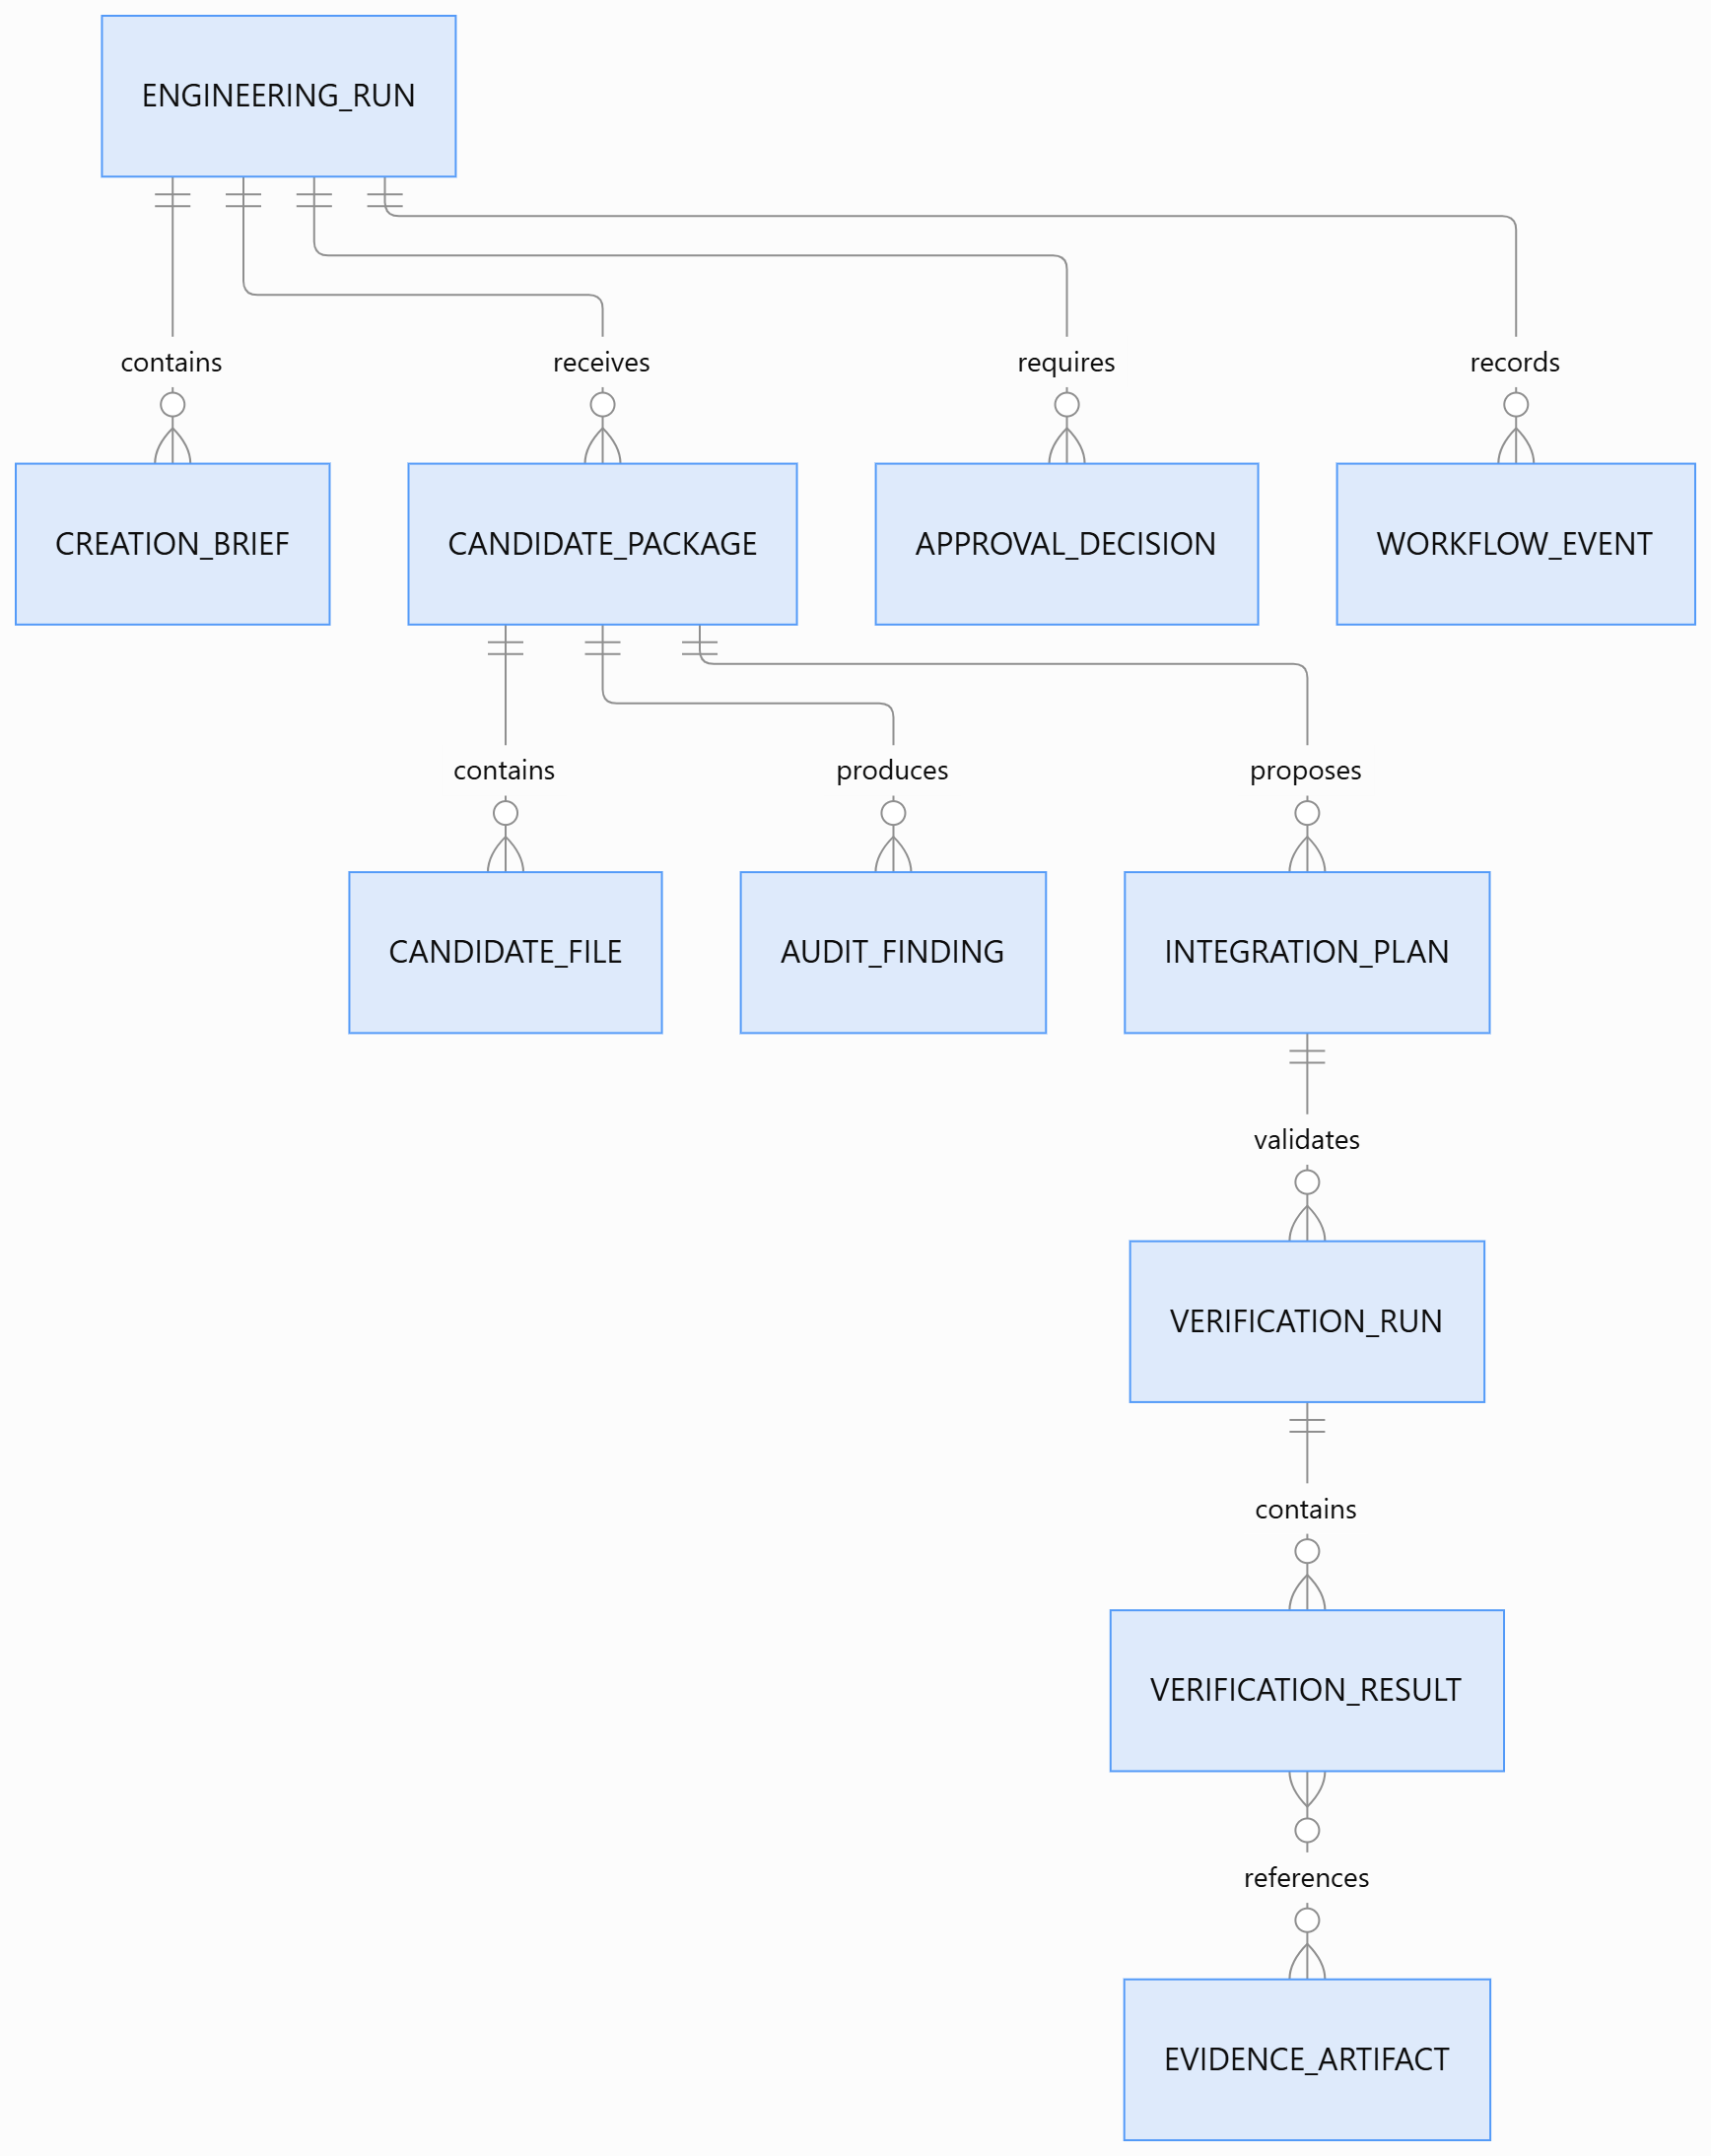


For the first implementation, a normal relational schema is sufficient. You do not need a vector database, Redis, Kafka or a graph database just to support this lifecycle.

## 10. API design

A compact initial API:

| Method | Endpoint                                 | Responsibility             |
| ------ | ---------------------------------------- | -------------------------- |
| POST   | `/api/project-llm/runs`                  | Start engineering run      |
| POST   | `/api/project-llm/runs/:id/discover`     | Inspect repository         |
| POST   | `/api/project-llm/runs/:id/brief`        | Generate Creation Brief    |
| POST   | `/api/project-llm/runs/:id/approvals`    | Record authorized decision |
| POST   | `/api/project-llm/runs/:id/candidates`   | Submit candidate           |
| POST   | `/api/project-llm/runs/:id/audit`        | Audit candidate            |
| POST   | `/api/project-llm/runs/:id/integration`  | Prepare integration        |
| POST   | `/api/project-llm/runs/:id/verification` | Start verification         |
| GET    | `/api/project-llm/runs/:id/evidence`     | Retrieve evidence          |
| GET    | `/api/project-llm/runs/:id`              | Retrieve lifecycle state   |

All mutation endpoints require authorization, state validation and audit logging. Gate 1 and Gate 2 decisions must use authenticated human identities; an agent cannot submit an approval on a human's behalf.

For long-running jobs, return a job identifier and expose status through polling or server-sent events.

# Part 3 — End-to-End MVP Plan

## 11. Select the first pilot

I recommend using SummaryBlock as the first engineering candidate, provided repository discovery confirms it is suitable.

Why SummaryBlock?

It should provide a useful test of the existing block schema, Composer registration, rendering, and applicable universal runtime contracts without initially introducing the complexity of interactive execution.

We should not assume it is simple until discovery verifies its actual dependencies.

### MVP success scenario

The human requests:

> Engineer a SummaryBlock variant for a React tutorial using the existing platform architecture.

The system must:

1. Inspect the repository.
2. Produce a valid Creation Brief.
3. Accept a human-approved external prototype.
4. Accept a React/TypeScript candidate.
5. Audit the candidate.
6. Prepare an integration patch.
7. Execute required verification.
8. Produce evidence.
9. Reach `CERTIFICATION_READY`.
10. Wait for human certification.

That is a meaningful, complete MVP.

## 12. Implementation plan

I recommend eight milestones, with duration estimates only after inspecting the existing codebase and test infrastructure.

| Milestone | Deliverable                 | Exit criterion                               |
| --------- | --------------------------- | -------------------------------------------- |
| M0        | Architecture reconciliation | Human-approved canonical decision            |
| M1        | Repository Discovery        | Accurate, source-backed repository snapshot  |
| M2        | Creation Brief              | Versioned, pasteable brief                   |
| M3        | Candidate Intake            | Secure parsing and independent manifest      |
| M4        | Audit Engine                | Deterministic findings and revision requests |
| M5        | Integration Engine          | Controlled, reviewable patch                 |
| M6        | Verification + Evidence     | Reproducible tests and linked evidence       |
| M7        | GUI + Human Gates           | Complete pilot lifecycle                     |

### M0 — Resolve the architectural contradiction

Before writing application code, reconcile:

- The Project LLM external-AI block lifecycle.
- The Phase 1B implementation contract.
- The architecture reconciliation document.
- The GUI-first strategy.
- The existing governance and runtime-boundary contracts.

The key decision is whether the narrow JSON-generation service remains a separate capability, is deferred, or is superseded through an authorized contract change.

Do not silently overwrite a locked contract. Record the human decision, affected contracts, compatibility implications and any required new version.

### M1 — Repository discovery

Build a discovery module that can answer:

- Where is the current Composer?
- How are block families registered?
- What schemas are authoritative?
- How does the renderer resolve blocks?
- Where are UBRC/ILS/LSNB/RSSB implemented?
- Which test commands are authoritative?
- Which directories are protected?

Acceptance test: Every important finding links to an actual file path and repository commit.

### M2 — Brief generator

Produce a self-contained brief suitable for copying into an external AI chat.

The brief should contain the objective, approved interfaces, relevant code references, required output format, forbidden changes and acceptance conditions.

Acceptance test: Two runs against the same repository snapshot and identical inputs produce semantically identical briefs, with no unsupported assumptions.

### M3 — Candidate intake

Support a ZIP upload or controlled multi-file submission. This avoids fragile parsing of large chat responses.

Intake must reject path traversal, unsupported file types, oversized packages, malformed structure and prohibited symlinks.

Acceptance test: The system independently inventories all accepted files and records their hashes.

### M4 — Candidate auditor

Build rules for:

- Unauthorized imports.
- Forbidden file modifications.
- Direct authentication or storage access where prohibited.
- Missing required block attributes.
- Invalid schema usage.
- Suspicious dependencies.
- Incompatible server/client boundaries.

Acceptance test: Deliberately defective fixtures trigger the expected findings.

### M5 — Integration engine

Start with deterministic patch generation.

The engine should identify existing registries and prepare only authorized changes. It should never assume that registration always involves the same files.

Acceptance test: The candidate integrates into an isolated worktree without modifying protected infrastructure or breaking existing block registrations.

### M6 — Verification and evidence

Execute the applicable validation matrix.

A representative suite includes:

| Test layer        | Example tooling                                  |
| ----------------- | ------------------------------------------------ |
| Type checking     | TypeScript                                       |
| Linting           | ESLint                                           |
| Unit tests        | Vitest/Jest                                      |
| Component tests   | Testing Library                                  |
| Integration tests | Existing project test runner                     |
| End-to-end tests  | Playwright                                       |
| Accessibility     | axe-core                                         |
| Responsive        | Playwright viewport tests                        |
| SSR               | Existing framework build/runtime tests           |
| Security          | AST rules, dependency checks, isolated execution |

Use the repository's actual tooling wherever possible instead of introducing parallel test frameworks.

Acceptance test: Every mandatory PASS has an artifact or reproducible command record, and missing evidence prevents certification readiness.

### M7 — GUI and human approval

The initial GUI should have these functional views:

| View                 | Main purpose                       |
| -------------------- | ---------------------------------- |
| Dashboard            | Engineering runs and blockers      |
| Repository Discovery | Inspect source-backed findings     |
| Creation Brief       | Review, version and copy brief     |
| Gate 1               | Approve/reject external prototype  |
| Candidate Intake     | Upload and review package          |
| Audit Findings       | Examine violations                 |
| Integration Review   | Inspect proposed patch             |
| Verification         | Review tests and failures          |
| Evidence             | Inspect artifacts                  |
| Gate 2               | Final human certification decision |

These can be consolidated into fewer routes with tabs; they do not need ten independently developed applications.

## 13. MVP completion criteria

The MVP is complete only when all the following conditions are demonstrated:

- One real block traverses the entire lifecycle.
- Both human approval gates are enforced.
- The system detects unauthorized universal-infrastructure changes.
- An invalid candidate receives a precise revision request.
- A corrected candidate can be resubmitted as a new revision.
- Integration uses the existing Composer and renderer.
- Required runtime compatibility checks execute.
- Evidence is independently generated.
- `CERTIFICATION_READY` is only assigned after mandatory checks pass.
- Final certification remains a human decision.
- The entire run is traceable to repository commit, candidate digest, test outputs and approvals.

Also run a deliberate negative test: submit a candidate that tries to modify a protected authentication or runtime file. The system must block or escalate it, not integrate it.

# 14. When to introduce Agentic AI

This is the crucial distinction between your initial implementation and the future platform.

### Version 1 — Deterministic engineering pipeline

```
Discovery
   ↓
Brief
   ↓
Candidate
   ↓
Audit
   ↓
Integration
   ↓
Verification
   ↓
Evidence
```

No LLM required.

### Version 2 — AI-assisted engineering

Introduce an optional local model for:

- Summarizing complex audit findings.
- Explaining repository dependencies.
- Drafting revision requests.
- Suggesting integration approaches.
- Helping humans understand failed checks.

The model proposes or explains. Deterministic validation and authorization still decide what can proceed.

### Version 3 — Bounded agentic orchestration

Add an agent that can choose among explicitly approved tools.



In [ ]:
flowchart TD
    U["Engineering Task"] --> A["Engineering Agent"]
    A --> P["Policy Check"]
    P --> T{"Allowed tool?"}
    T -- No --> H["Escalate to Human"]
    T -- Yes --> X["Execute Tool"]
    X --> V["Verify Result"]
    V --> E{"Goal achieved?"}
    E -- No, within limits --> A
    E -- Yes --> R["Evidence-backed Result"]
    E -- Blocked --> H

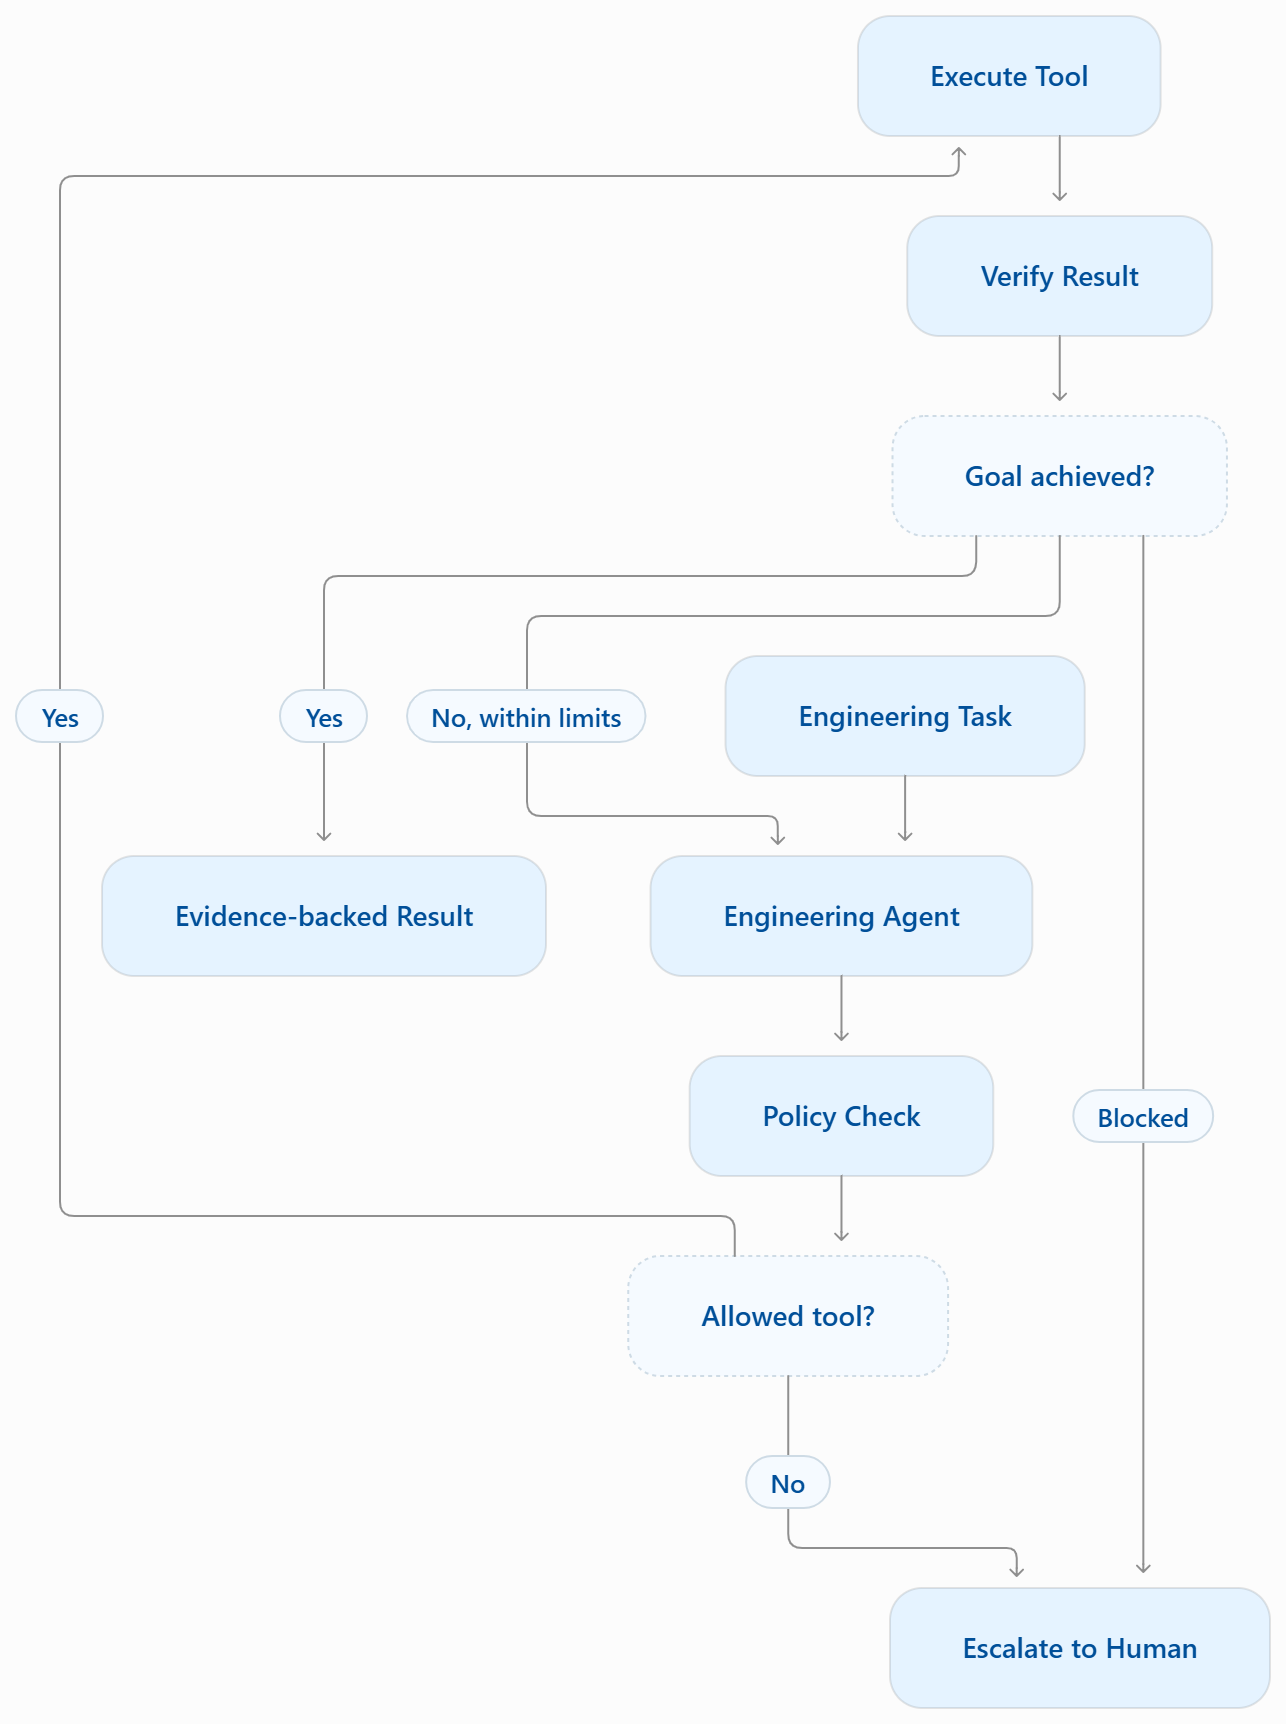

The agent must have execution limits, approved tool scopes, maximum retry counts and clear stop conditions.

### Version 4 — Model portability

Introduce Ollama or vLLM behind the model interface and benchmark candidate models on your actual engineering tasks.

Only then consider model routing or fine-tuning.

# 15. The immediate execution order

Here is the sequence I recommend following, without starting another large speculative documentation exercise.

| Priority | Work item                                   | Deliverable                       |
| -------- | ------------------------------------------- | --------------------------------- |
| P0       | Verify authoritative repository documents   | Source/contract inventory         |
| P0       | Resolve lifecycle vs Phase 1B contradiction | Approved architecture decision    |
| P0       | Confirm protected files and approval rules  | Enforceable policy map            |
| P1       | Implement repository discovery              | Working discovery command/API     |
| P1       | Implement brief generation                  | First real SummaryBlock brief     |
| P1       | Implement candidate intake                  | Secure candidate inventory        |
| P1       | Implement static auditing                   | Executable rule suite             |
| P2       | Implement isolated integration              | Reviewable Git patch              |
| P2       | Implement verification                      | Reproducible evidence             |
| P2       | Implement human gates and GUI               | Complete end-to-end pilot         |
| P3       | Add optional local AI                       | Measured productivity improvement |

## My recommendation for your very next action

Start with M0: Architecture Reconciliation, followed immediately by M1: Repository Discovery.

The first deliverable should be a concise, approved `PROJECT_LLM_CANONICAL_ARCHITECTURE_V1.md` that identifies exactly which existing contracts remain authoritative, which conflict, and what decisions require your approval.

I could not independently retrieve the live repository contents in this turn, so the proposed paths and interfaces above are implementation recommendations rather than verified matches to your codebase. For the next step, provide a ZIP of the repository or connect GitHub so the actual code and Markdown contracts can be inspected together.

Once that is available, we can replace this proposed design with a repository-verified implementation specification and begin building the deterministic Project LLM core without unnecessarily changing your existing architecture.

The final objective remains:

External AI designs and produces the candidate. Project LLM inspects, integrates, tests and proves readiness. Human authority approves and certifies.